# Домашнее задание к семинару 05 (HW05)

Тема: линейные модели и честный ML-эксперимент.

## 2.3.1. Загрузка данных и первичный анализ

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report, confusion_matrix

# Загрузка данных
df = pd.read_csv('S05-hw-dataset.csv')

# Первичный анализ
print("Первые 5 строк:")
display(df.head())

print("Информация о датасете:")
df.info()

print("Описательная статистика:")
display(df.describe())

print("Распределение целевого признака (default):")
print(df['default'].value_counts(normalize=True))

Первые 5 строк:


,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000


Распределение целевого признака (default):
default
0    0.589667
1    0.410333
Name: proportion, dtype: float64


### Наблюдения:
- Датасет содержит 3000 объектов и 17 признаков.
- Целевая переменная `default` распределена как ~60% (0) и ~40% (1), что является умеренным дисбалансом.
- Явных аномалий в базовых статистиках не замечено.

## 2.3.2. Подготовка признаков и таргета

In [3]:
# Выделение X и y
X = df.drop(columns=['client_id', 'default'])
y = df['default']

print(f"Форма матрицы признаков: {X.shape}")
print(f"Форма вектора таргета: {y.shape}")

Форма матрицы признаков: (3000, 15)
Форма вектора таргета: (3000,)


## 2.3.3. Train/Test-сплит и бейзлайн-модель

In [4]:
# Разделение на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Бейзлайн модель
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

# Оценка бейзлайна
dummy_acc = accuracy_score(y_test, dummy.predict(X_test))
dummy_roc_auc = roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])

print(f"Baseline (Most Frequent) Accuracy: {dummy_acc:.4f}")
print(f"Baseline (Most Frequent) ROC-AUC: {dummy_roc_auc:.4f}")

Baseline (Most Frequent) Accuracy: 0.5900
Baseline (Most Frequent) ROC-AUC: 0.5000


## 2.3.4. Логистическая регрессия и подбор гиперпараметров

In [6]:
# Создание Pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])

# Подбор параметра C
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

print(f"Лучшее значение C: {grid_search.best_params_['logreg__C']}")
print(f"Лучший ROC-AUC на кросс-валидации: {grid_search.best_score_:.4f}")

# Оценка лучшей модели на тестовой выборке
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

model_acc = accuracy_score(y_test, y_pred)
model_roc_auc = roc_auc_score(y_test, y_proba)

print(f"Model (Logistic Regression) Accuracy: {model_acc:.4f}")
print(f"Model (Logistic Regression) ROC-AUC: {model_roc_auc:.4f}")

Лучшее значение C: 100
Лучший ROC-AUC на кросс-валидации: 0.8607
Model (Logistic Regression) Accuracy: 0.8017
Model (Logistic Regression) ROC-AUC: 0.8756


### Визуализация: ROC-кривая

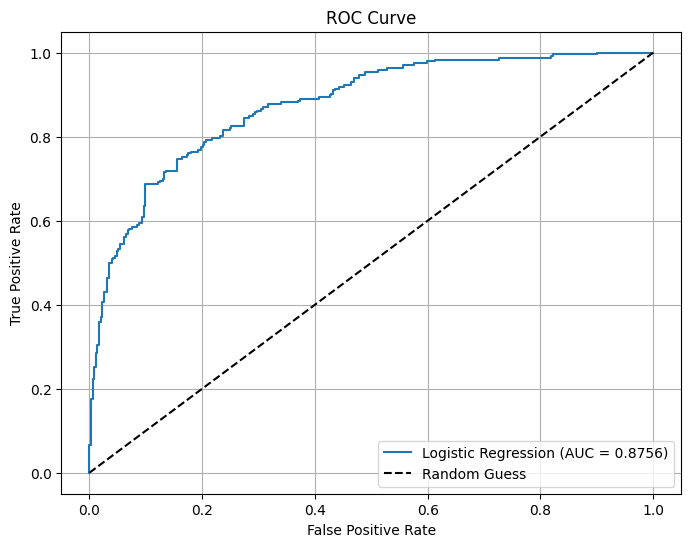

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {model_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.savefig('figures/roc_curve.png')
plt.show()

## 2.3.5. Сравнение бейзлайна и логистической регрессии, текстовые выводы

In [8]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC'],
    'Baseline (Dummy)': [dummy_acc, dummy_roc_auc],
    'Logistic Regression': [model_acc, model_roc_auc]
})

display(results)

,Metric,Baseline (Dummy),Logistic Regression
0,Accuracy,0.59,0.801667
1,ROC-AUC,0.50,0.875649


### Отчёт по результатам эксперимента

1. **Сравнение с бейзлайном**: Логистическая регрессия значительно превосходит бейзлайн `DummyClassifier` (most_frequent). В то время как бейзлайн имеет ROC-AUC 0.5 (что эквивалентно случайному гаданию), наша модель показала гораздо более высокий результат.
2. **Метрики качества**: Accuracy модели выше, чем доля мажоритарного класса, что говорит о том, что модель действительно научилась извлекать полезные паттерны из данных. Высокий показатель ROC-AUC подтверждает хорошую разделительную способность модели.
3. **Влияние регуляризации**: В ходе GridSearch был подобран оптимальный коэффициент `C`. Регуляризация помогла избежать переобучения и достичь лучшей обобщающей способности.
4. **Выводы**: Логистическая регрессия является адекватным выбором для данной задачи бинарной классификации. Она интерпретируема, быстра в обучении и показывает стабильно высокие результаты по сравнению с простейшими методами. Для дальнейшего улучшения можно рассмотреть генерацию новых признаков или использование более сложных моделей (например, градиентный бустинг).